# Evaluate: 1D pitch contour vs. 2D pitch-salience image

Compares subsequence-DTW query-by-humming matching using a 1D cents contour against a 2D rasterised pitch-salience image, at several Gaussian blur widths. Queries and reference songs are already on disk under `data/queries/` and `data/references/`; each song's vocals are isolated with Demucs before pitch extraction.

In [7]:
%matplotlib inline
import time
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import plots, utils
from tqdm.auto import tqdm

PALETTE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#F0E442", "#000000"]
plots.set_style(PALETTE)

DATA_ROOT = Path("data")
CACHE_ROOT = Path(".cache")
PITCH = {"sr": 22050, "fmin": 80.0, "fmax": 1000.0, "frame_length": 2048, "hop_seconds": 0.025}
EVAL = {"hop_seconds": 0.1, "f_ref": 55.0, "bin_cents": 25, "range_cents": 2400, "norm_window_s": 12.0}
N_QUERIES = None
SIGMAS = [0, 50, 100, 200]

## Load pitch tracks

In [8]:
index = pd.read_csv(DATA_ROOT / "queries_index.csv")
if N_QUERIES:
    index = index.sample(N_QUERIES, random_state=0).reset_index(drop=True)

query_cache = CACHE_ROOT / "pitch" / "queries"
ref_cache = CACHE_ROOT / "pitch" / "references"
demucs_cache = CACHE_ROOT / "demucs"

query_tracks = {k: utils.extract_f0(p, query_cache, PITCH) for k, p in zip(index.query_id, DATA_ROOT / index.path)}

reference_vocals = {sid: utils.separate_vocals(DATA_ROOT / "references" / f"{sid}.wav", demucs_cache)
                    for sid in tqdm(index.song_id.unique(), desc="separating vocals")}
ref_tracks = {sid: utils.extract_f0(path, ref_cache / str(sid), PITCH)
              for sid, path in tqdm(reference_vocals.items(), desc="pYIN (references)")}

len(query_tracks), len(ref_tracks)

separating vocals:   0%|          | 0/55 [00:00<?, ?it/s]

pYIN (references):   0%|          | 0/55 [00:00<?, ?it/s]

(86, 55)

## Build the 1D and 2D representations

In [9]:
q_cents = [utils.to_contour(query_tracks[k], True, EVAL, PITCH) for k in index.query_id]
r_cents = {sid: utils.to_contour(t, False, EVAL, PITCH) for sid, t in ref_tracks.items()}
true_ids = index.song_id.astype(int).tolist()

q_1d = [utils.fill_gaps(c)[None, :] for c in q_cents]
r_1d = {sid: utils.fill_gaps(c)[None, :] for sid, c in r_cents.items()}

def images(sigma):
    return ([utils.to_salience_image(c, EVAL, sigma) for c in q_cents],
            {sid: utils.to_salience_image(c, EVAL, sigma) for sid, c in r_cents.items()})

/home/vivekv/Desktop/Strawberry-Fields/notebooks/utils.py:133: RuntimeWarning: All-NaN slice encountered
  out = np.nanmedian(blocks, axis=1)


## Example representations

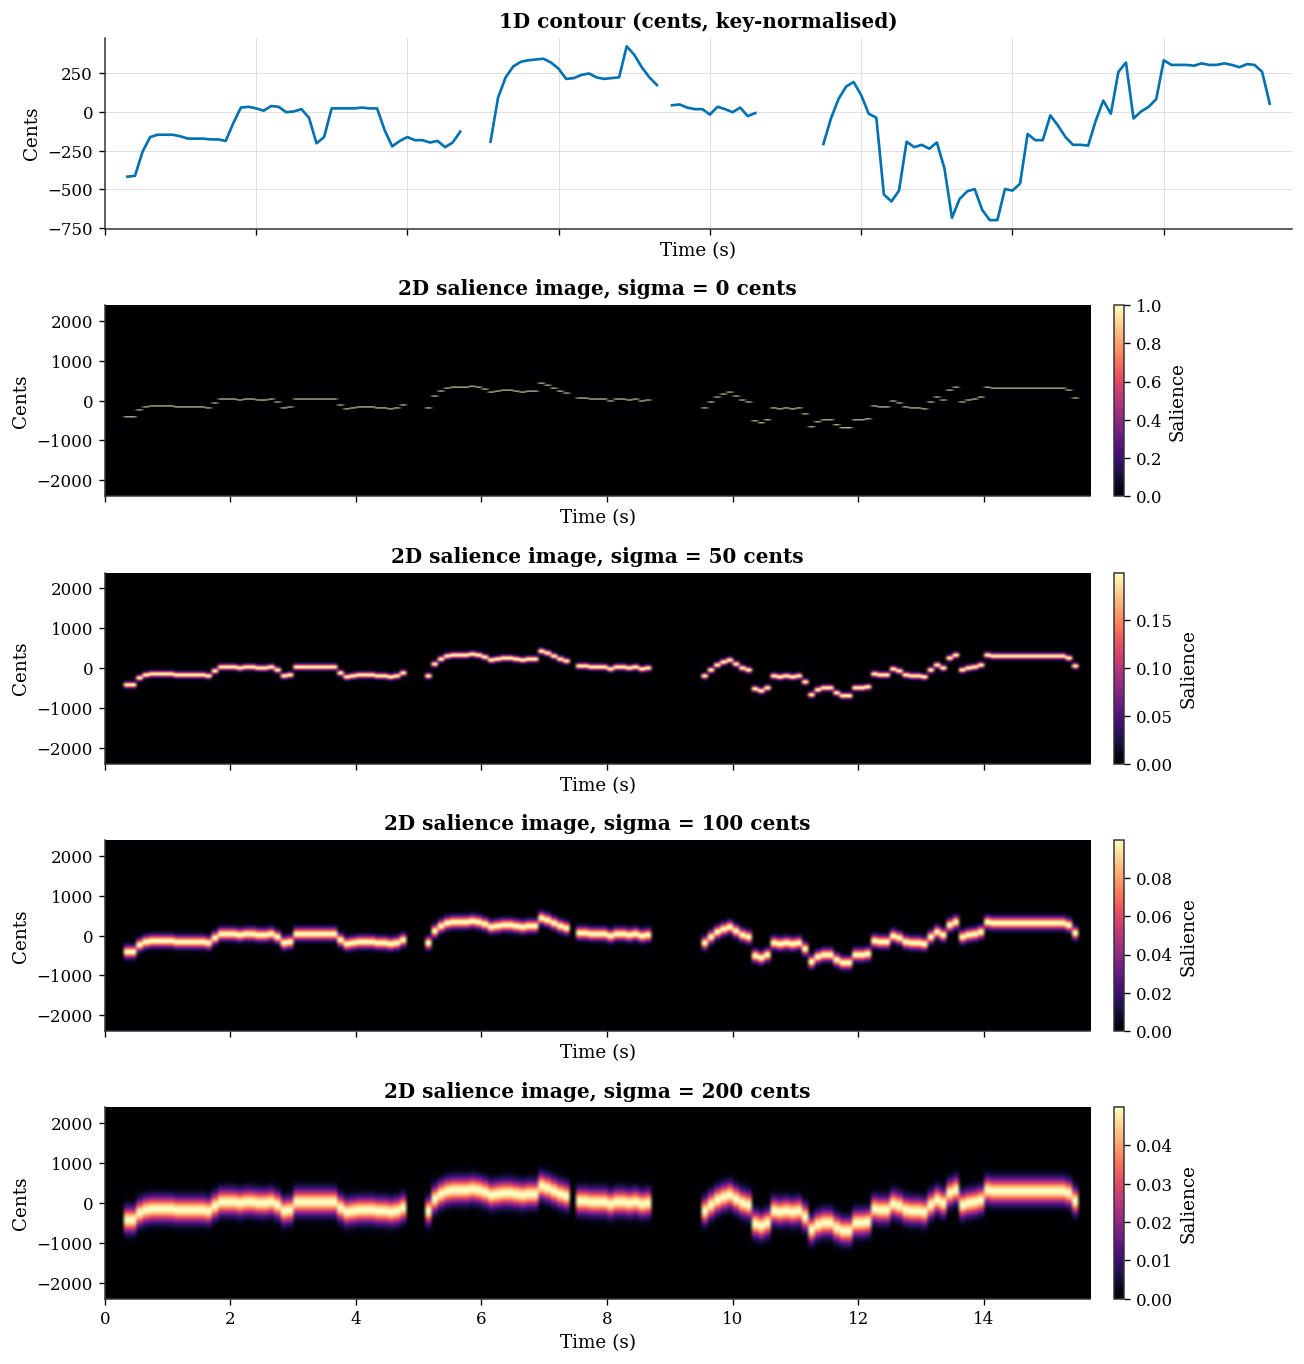

In [10]:
example_query = 0
fig, axes = plt.subplots(1 + len(SIGMAS), 1, figsize=(11, 2.3 * (1 + len(SIGMAS))), sharex=True)
plots.plot_contour(axes[0], q_cents[example_query], EVAL, title="1D contour (cents, key-normalised)", color=PALETTE[0])
for ax, sigma in zip(axes[1:], SIGMAS):
    plots.plot_salience_image(ax, utils.to_salience_image(q_cents[example_query], EVAL, sigma), EVAL,
                               title=f"2D salience image, sigma = {sigma} cents")
axes[-1].set_xlabel("Time (s)")
fig.tight_layout()

## Rank queries under each representation

In [11]:
results = {}

t0 = time.perf_counter()
ranks, costs, song_ids = utils.rank_queries(q_1d, r_1d, true_ids, metric="cityblock", desc="1D contour")
results["1D contour"] = {"ranks": ranks, "costs": costs, "song_ids": song_ids,
                          "seconds": (time.perf_counter() - t0) / len(q_1d)}

for sigma in SIGMAS:
    name = f"2D image (sigma={sigma})"
    q_img, r_img = images(sigma)
    t0 = time.perf_counter()
    ranks, costs, song_ids = utils.rank_queries(q_img, r_img, true_ids, metric="euclidean", desc=name)
    results[name] = {"ranks": ranks, "costs": costs, "song_ids": song_ids,
                      "seconds": (time.perf_counter() - t0) / len(q_img)}

table = pd.DataFrame({
    name: {**utils.summarise(r["ranks"]), "seconds / query": r["seconds"]}
    for name, r in results.items()
}).T
table

1D contour:   0%|          | 0/86 [00:00<?, ?it/s]

2D image (sigma=0):   0%|          | 0/86 [00:00<?, ?it/s]

2D image (sigma=50):   0%|          | 0/86 [00:00<?, ?it/s]

2D image (sigma=100):   0%|          | 0/86 [00:00<?, ?it/s]

2D image (sigma=200):   0%|          | 0/86 [00:00<?, ?it/s]

,top-1,top-3,top-5,top-10,MRR,median rank,mean rank,seconds / query
1D contour,0.151163,0.267442,0.313953,0.430233,0.249652,14.5,18.476744,0.494120
2D image (sigma=0),0.011628,0.127907,0.162791,0.255814,0.109768,24.0,25.360465,4.241921
2D image (sigma=50),0.186047,0.279070,0.337209,0.430233,0.277744,12.5,18.546512,4.302587
2D image (sigma=100),0.220930,0.383721,0.476744,0.581395,0.340893,6.5,13.872093,4.182401
2D image (sigma=200),0.255814,0.441860,0.534884,0.627907,0.384241,5.0,12.046512,4.171043


## Top-k accuracy and cumulative accuracy

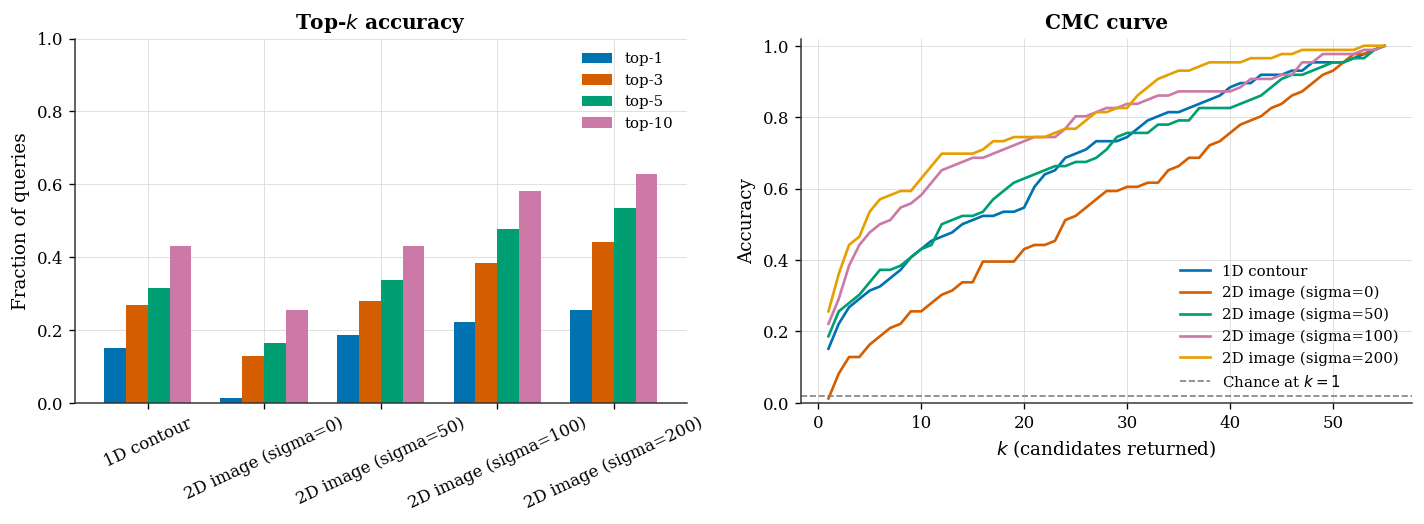

In [12]:
ranks_by_name = {name: r["ranks"] for name, r in results.items()}
n_candidates = len(next(iter(results.values()))["song_ids"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plots.plot_top_k_bar(axes[0], table)
plots.plot_cmc_curve(axes[1], ranks_by_name, n_candidates)
fig.tight_layout()

## Mean reciprocal rank, rank histogram and timing

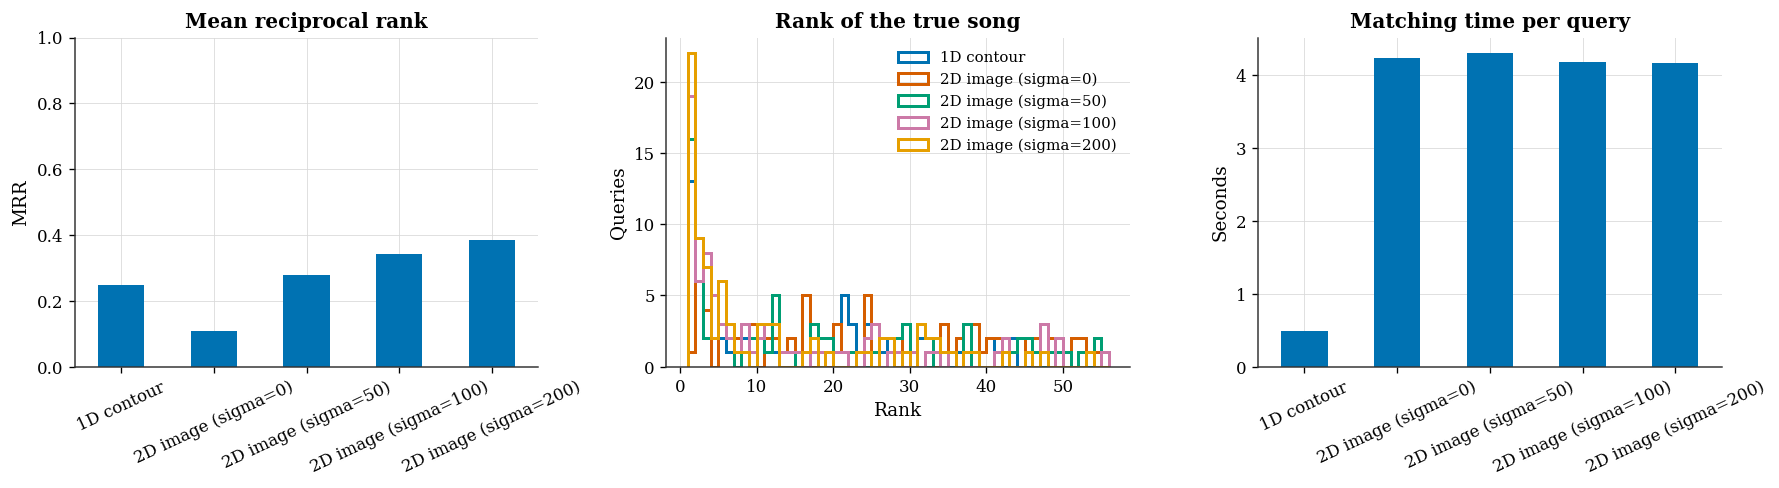

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
plots.plot_mrr_bar(axes[0], table)
plots.plot_rank_histogram(axes[1], ranks_by_name, n_candidates)
plots.plot_timing_bar(axes[2], table)
fig.tight_layout()

## Genuine vs. impostor cost distributions

{'1D contour': 0.5760070508583218,
 '2D image (sigma=0)': 0.5108654828435791,
 '2D image (sigma=50)': 0.5824995493059311,
 '2D image (sigma=100)': 0.639186847745528,
 '2D image (sigma=200)': 0.654149890831881}

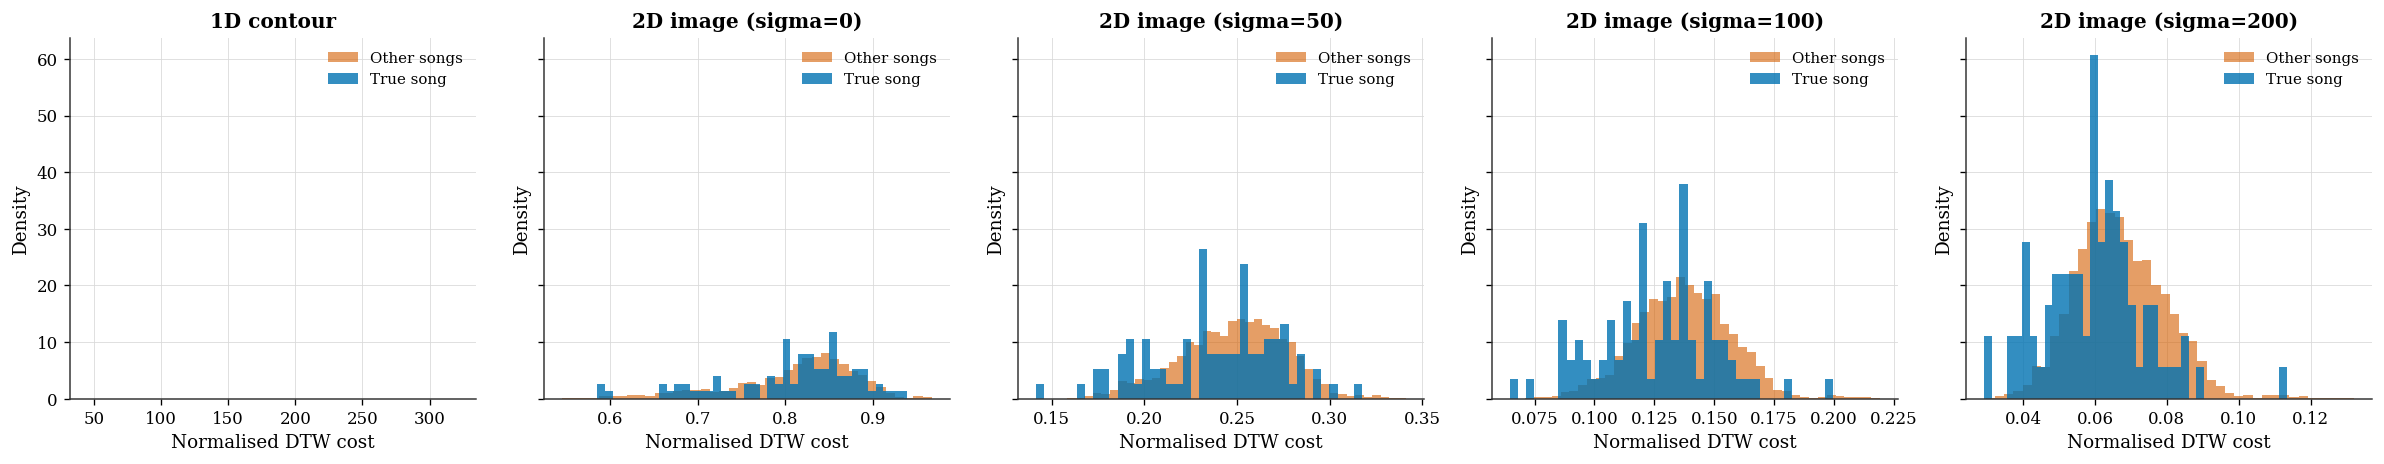

In [14]:
costs_by_name = {name: r["costs"] for name, r in results.items()}
true_cols = np.array([results["1D contour"]["song_ids"].index(t) for t in true_ids])

fig, axes = plt.subplots(1, len(costs_by_name), figsize=(4 * len(costs_by_name), 4), sharey=True)
auc = plots.plot_cost_distributions(axes, costs_by_name, true_cols,
                                     genuine_color=PALETTE[0], impostor_color=PALETTE[1])
fig.tight_layout()
auc

## Paired comparison: 1D contour vs. the best 2D image

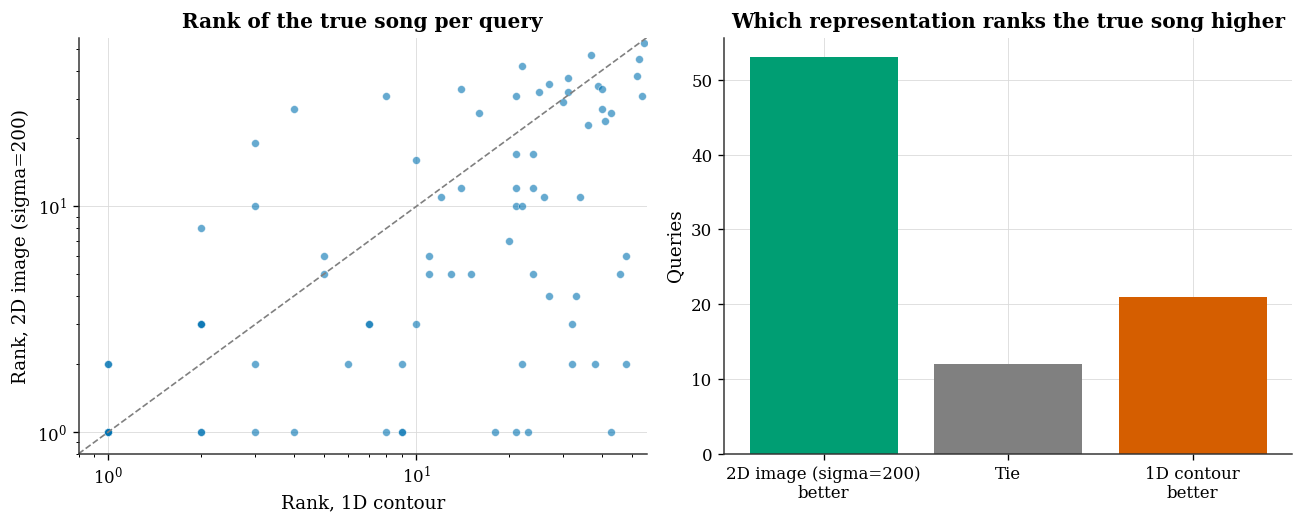

In [15]:
best_2d = table.drop(index="1D contour")["MRR"].idxmax()

fig, (ax_scatter, ax_bar) = plt.subplots(1, 2, figsize=(11, 4.5))
plots.plot_paired_ranks(ax_scatter, ax_bar,
                         ranks_by_name["1D contour"], ranks_by_name[best_2d],
                         "1D contour", best_2d, n_candidates,
                         point_color=PALETTE[0], better_color=PALETTE[2],
                         worse_color=PALETTE[1], tie_color="gray")
fig.tight_layout()

## Which queries fail with the best 2D setting?

In [16]:
failed = index.assign(rank_1d=ranks_by_name["1D contour"], rank_2d=ranks_by_name[best_2d])
failed = failed[failed.rank_2d > 1].sort_values("rank_2d", ascending=False)
print(f"{len(failed)} of {len(index)} queries not ranked first by {best_2d}")
failed[["query_id", "title", "original_artist", "song_id", "rank_1d", "rank_2d"]].head(15)

64 of 86 queries not ranked first by 2D image (sigma=200)


,query_id,title,original_artist,song_id,rank_1d,rank_2d
84,q116,You really got me,The Kinks,2024,55,53
74,q103,What a wonderful world,Louis Armstrong,1835,37,47
24,q33,My Sharona,The Knack,2031,53,45
57,q77,Help,The Beatles,668,22,42
67,q93,Cecilia,Simon and Garfunkel,2086,52,38
69,q97,Imagine,John Lennon,768,31,37
71,q99,No woman no cry,Bob Marley,1209,27,35
10,q14,Hello goodbye,The Beatles,663,39,34
33,q44,What a wonderful world,Louis Armstrong,1835,14,33
21,q29,Nothing else matters,Metallica,1194,40,33
